In [69]:
import pandas as pd
import seaborn as sns
from sklearn import tree
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, accuracy_score
from sklearn import datasets
from sklearn import cluster
from sklearn import svm
from sklearn import tree
from sklearn import model_selection
sns.set_theme(palette='colorblind')

In [71]:
path = '/Users/mayageva/Downloads/seeds_dataset.txt'
df = pd.read_csv(path,sep="	")
column_names = ['area','perimeter','compactness','length','width','asymmetry','groove_length','variety']
df.columns = column_names
#for variety: 1 = Kama, 2 = Rosa and 3 = Canadian

In [73]:
Y = df['variety']
X = df.drop(['variety'],axis=1)
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,random_state=5)

In [75]:
# create dt,
dt = tree.DecisionTreeClassifier()

# set param grid 
params_dt = {'criterion':['gini','entropy'],
       'max_depth':[2,3,4,5,6],
    'min_samples_leaf':list(range(2,20,2))}
# create optimizer
dt_opt = model_selection.GridSearchCV(dt,params_dt,cv=10)


# optimize the dt parameters
dt_opt.fit(X_train,y_train)

# store the results in a dataframe
dt_df = pd.DataFrame(dt_opt.cv_results_)


# create svm, its parameter grid and optimizer
svm_clf = svm.SVC()
param_grid = {'kernel':['linear','rbf'], 'C':[.5, .75,1,2,5,7, 10]}
svm_opt = model_selection.GridSearchCV(svm_clf,param_grid,cv=10)

# optmize the svm put the CV results in a dataframe
svm_opt.fit(X_train,y_train)
sv_df = pd.DataFrame(svm_opt.cv_results_)

In [89]:
dt_df.loc[dt_df['rank_test_score'].idxmin()]

mean_fit_time                                                      0.000498
std_fit_time                                                       0.000005
mean_score_time                                                    0.000263
std_score_time                                                     0.000001
param_criterion                                                     entropy
param_max_depth                                                           5
param_min_samples_leaf                                                    4
params                    {'criterion': 'entropy', 'max_depth': 5, 'min_...
split0_test_score                                                       1.0
split1_test_score                                                  0.941176
split2_test_score                                                  0.823529
split3_test_score                                                  0.941176
split4_test_score                                                  0.941176
split5_test_

In [91]:
sv_df.loc[sv_df['rank_test_score'].idxmin()]

mean_fit_time                            0.000445
std_fit_time                             0.000014
mean_score_time                          0.000282
std_score_time                           0.000003
param_C                                         1
param_kernel                               linear
params               {'C': 1, 'kernel': 'linear'}
split0_test_score                             1.0
split1_test_score                        0.941176
split2_test_score                        0.941176
split3_test_score                        0.882353
split4_test_score                        0.823529
split5_test_score                        0.941176
split6_test_score                             1.0
split7_test_score                            0.75
split8_test_score                             1.0
split9_test_score                          0.9375
mean_test_score                          0.921691
std_test_score                           0.077748
rank_test_score                                 1


In [101]:
# Decision tree confusion matrix
y_pred_dt = dt_opt.predict(X_test)
confusion_matrix(y_test, y_pred_dt)

array([[13,  0,  0],
       [ 0, 12,  0],
       [ 2,  0, 15]])

In [103]:
print(classification_report(y_test,y_pred_dt))

              precision    recall  f1-score   support

           1       0.87      1.00      0.93        13
           2       1.00      1.00      1.00        12
           3       1.00      0.88      0.94        17

    accuracy                           0.95        42
   macro avg       0.96      0.96      0.96        42
weighted avg       0.96      0.95      0.95        42



In [105]:
#Svm confusion matrix

In [107]:
y_pred_svm = svm_opt.predict(X_test)
confusion_matrix(y_test, y_pred_svm)

array([[12,  1,  0],
       [ 0, 12,  0],
       [ 1,  0, 16]])

In [109]:
print(classification_report(y_test,y_pred_svm))

              precision    recall  f1-score   support

           1       0.92      0.92      0.92        13
           2       0.92      1.00      0.96        12
           3       1.00      0.94      0.97        17

    accuracy                           0.95        42
   macro avg       0.95      0.95      0.95        42
weighted avg       0.95      0.95      0.95        42



In [111]:
# They have an equal recall
# Decision tree has a higher precision
# they have an equal f1 score

In [117]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
comparison_table = pd.DataFrame({
    'Model': ["Decision Tree", "SVM"],
    'Mean test score': [dt_opt.best_score_, svm_opt.best_score_],
    'Accuracy': [accuracy_dt, accuracy_svm],
    'Fit time': [dt_df['mean_fit_time'].min(), sv_df['mean_fit_time'].min()],
    'Prediction time': [dt_df['mean_score_time'].min(), sv_df['mean_score_time'].min()],
})

In [119]:
comparison_table

,Model,Mean Test Score,Accuracy,Fit Time,Prediction Time
0,Decision Tree,0.915809,0.952381,0.000408,0.000260
1,SVM,0.921691,0.952381,0.000437,0.000273


<Axes: >

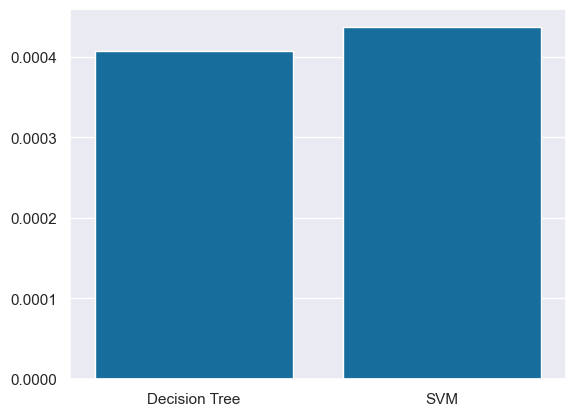

In [140]:
sns.barplot(x=["Decision Tree", "SVM"], y=[dt_df['mean_fit_time'].min(), sv_df['mean_fit_time'].min()])

<Axes: >

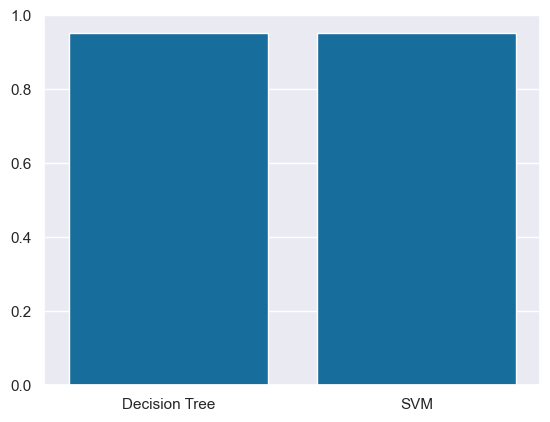

In [136]:
#Bar plot for accuracy
sns.barplot(x=["Decision Tree", "SVM"], y=[accuracy_dt, accuracy_svm])

<Axes: >

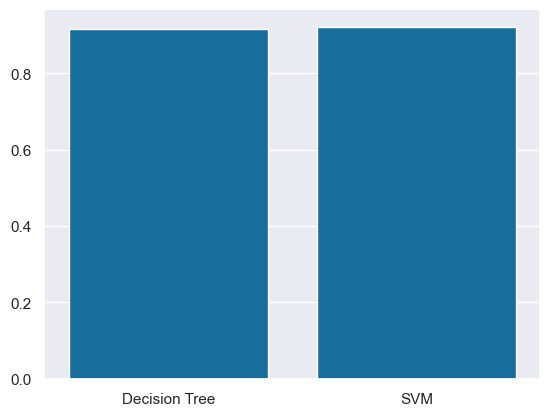

In [138]:
#Bar plot for Mean Test score
sns.barplot(x=["Decision Tree", "SVM"], y=[dt_opt.best_score_, svm_opt.best_score_])

Overall, I would use decision because it has a slightly higher accuracy, along with a shorter fit time and prediction time. However, svm has a slightly higher mean test score. In a real world scenerio where we are trying to classify different species of a plant, I think that accuracy, fit time, and prediction time will be very important factors to decide which model to use, and because of this, I think that decision tree is the better preforming model for this scenario.